In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [49]:
df_raw = pd.read_csv(r"C:\Users\Nadimul haque\Downloads\Telco_Customer_Churn_Dataset  (3).csv")
print("Shape:", df_raw.shape)
print("\nFirst 5 rows:")
df_raw.head()

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [87]:
# 2. Data Exploration 
print("Dataset Info:")
df_raw.info()
print("\nBasic Statistics:")
df_raw.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [89]:
# 3. Handle TotalCharges & Missing Values
df = df_raw.copy()  # always work on a copy!

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing before fix:", df.isnull().sum().sum())

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print("Missing after fix:", df.isnull().sum().sum())

Missing before fix: 11
Missing after fix: 0


In [91]:
#  4. Drop customerID 
df.drop('customerID', axis=1, inplace=True)
print("Columns after drop:", df.shape[1])

Columns after drop: 20


In [93]:
#  5. Encode Target Variable 
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print("Churn distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].mean()*100:.2f}%")

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Rate: 26.54%


In [95]:
# 6. Encode Categorical Variables 
# Keep a copy for EDA BEFORE encoding
df_eda = df.copy()

# One-hot encode
df_encoded = pd.get_dummies(df, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [97]:
#  7. Split Dataset 
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (5634, 30) | Test: (1409, 30)


In [99]:
# TASK 2: EXPLORATORY DATA ANALYSIS (EDA)
# Note: Using df_eda (before encoding) for readable charts
CHURN_COLORS = ['#2ecc71', '#e74c3c']
sns.set_theme(style="whitegrid")

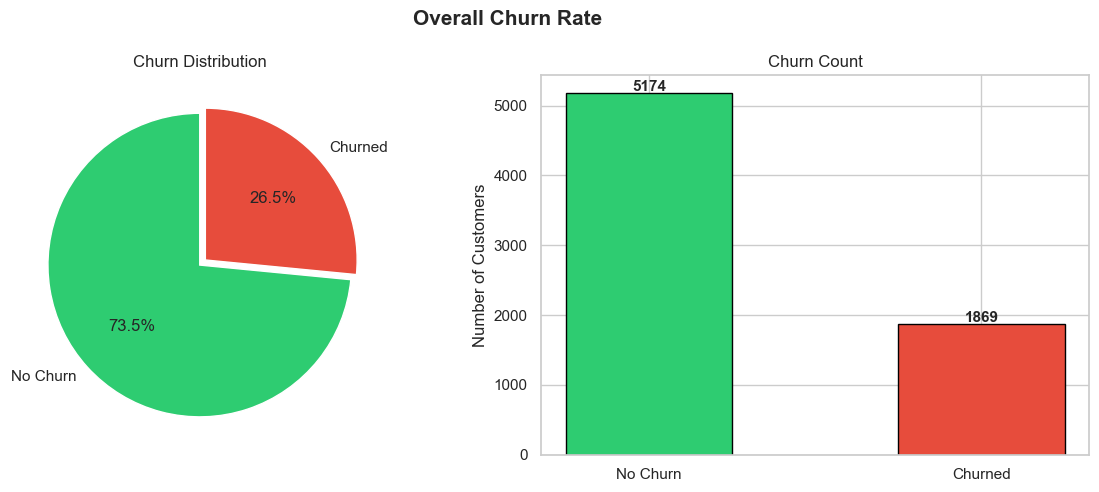

Churn Rate: 26.54%


In [101]:
#  Plot 1: Overall Churn Rate 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Overall Churn Rate', fontsize=15, fontweight='bold')

churn_counts = df_eda['Churn'].value_counts()
labels = ['No Churn', 'Churned']

axes[0].pie(churn_counts, labels=labels, autopct='%1.1f%%',
            colors=CHURN_COLORS, startangle=90, explode=(0, 0.05))
axes[0].set_title('Churn Distribution')

bars = axes[1].bar(labels, churn_counts, color=CHURN_COLORS,
                   edgecolor='black', width=0.5)
for bar, count in zip(bars, churn_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{count}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
axes[1].set_title('Churn Count')

plt.tight_layout()
plt.savefig('task2_plot1_churn_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Churn Rate: {df_eda['Churn'].mean()*100:.2f}%")

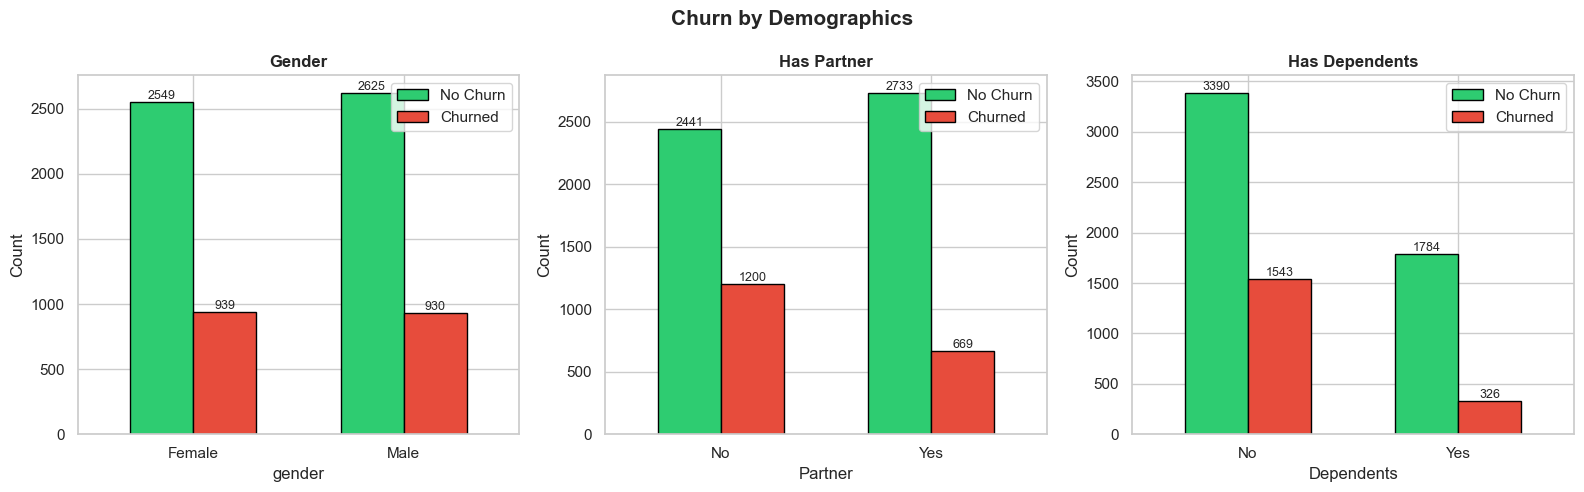

In [67]:
# ── Plot 2: Demographics (Gender, Partner, Dependents) ───────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Churn by Demographics', fontsize=15, fontweight='bold')

for ax, col, title in zip(axes,
                           ['gender', 'Partner', 'Dependents'],
                           ['Gender', 'Has Partner', 'Has Dependents']):
    data = df_eda.groupby([col, 'Churn']).size().unstack()
    data.plot(kind='bar', ax=ax, color=CHURN_COLORS,
              edgecolor='black', rot=0, width=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    ax.legend(['No Churn', 'Churned'])
    for container in ax.containers:
        ax.bar_label(container, fontsize=9)

plt.tight_layout()
plt.savefig('task2_plot2_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

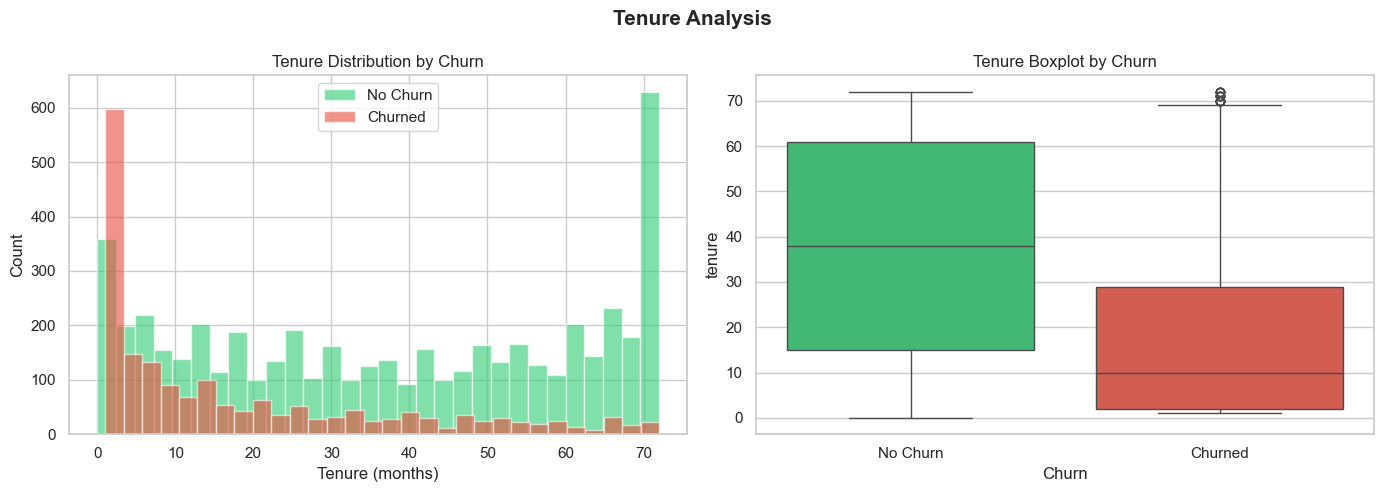

Avg tenure No Churn: 37.6 months
Avg tenure Churned:  18.0 months


In [109]:
# Plot 3: Tenure vs Churn 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tenure Analysis', fontsize=15, fontweight='bold')

for val, color, label in zip([0, 1], CHURN_COLORS, ['No Churn', 'Churned']):
    axes[0].hist(df_eda[df_eda['Churn']==val]['tenure'],
                 bins=30, alpha=0.6, color=color, label=label)
axes[0].set_title('Tenure Distribution by Churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].legend()

# ✅ FINAL FIX: no dict, no hue, just a color list
sns.boxplot(x='Churn', y='tenure', data=df_eda,
            palette=['#2ecc71', '#e74c3c'],
            ax=axes[1])

axes[1].set_title('Tenure Boxplot by Churn')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Churn', 'Churned'])

plt.tight_layout()
plt.savefig('task2_plot3_tenure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avg tenure No Churn: {df_eda[df_eda['Churn']==0]['tenure'].mean():.1f} months")
print(f"Avg tenure Churned:  {df_eda[df_eda['Churn']==1]['tenure'].mean():.1f} months")

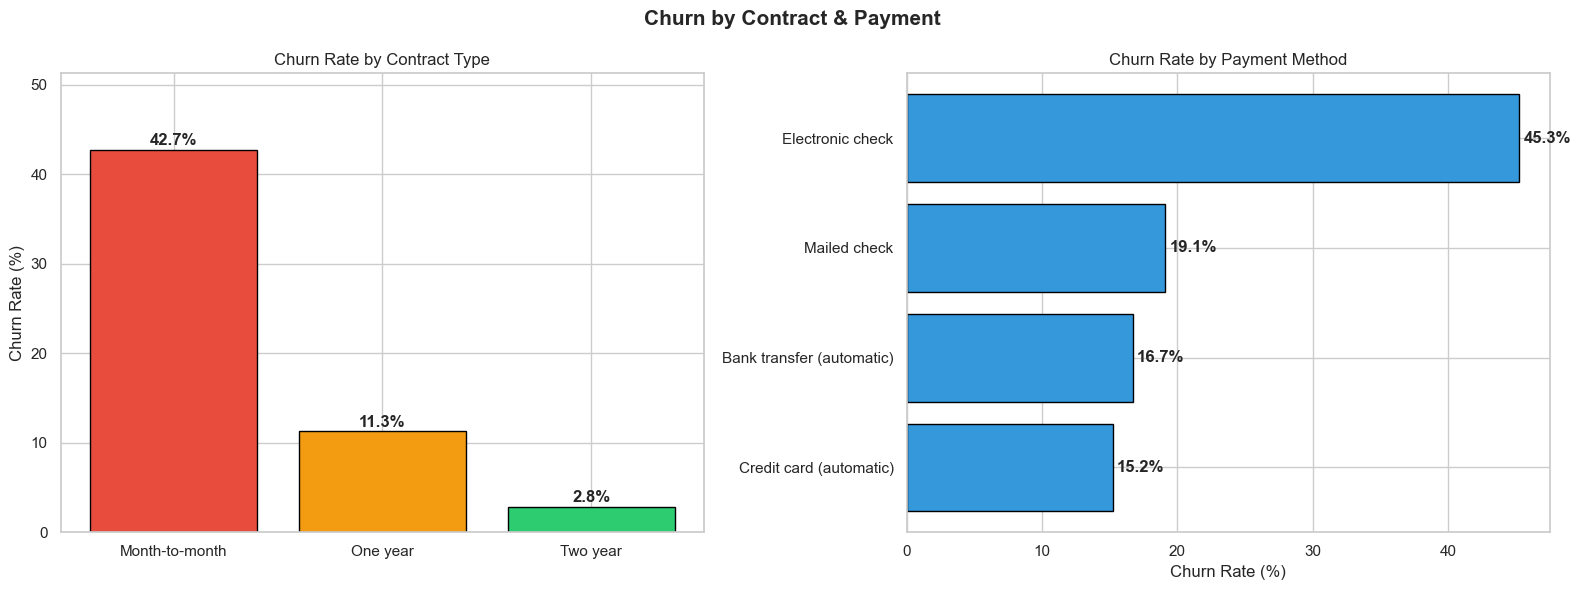

Task 2 Complete!


In [105]:
# Plot 4: Contract Type & Payment Method 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Churn by Contract & Payment', fontsize=15, fontweight='bold')

# Contract type churn rate
contract_churn = df_eda.groupby('Contract')['Churn'].mean() * 100
bars = axes[0].bar(contract_churn.index, contract_churn.values,
                   color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, contract_churn.max() * 1.2)

# Payment method churn rate
payment_churn = (df_eda.groupby('PaymentMethod')['Churn']
                 .mean() * 100).sort_values()
axes[1].barh(payment_churn.index, payment_churn.values,
             color='#3498db', edgecolor='black')
for i, val in enumerate(payment_churn.values):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontweight='bold')
axes[1].set_title('Churn Rate by Payment Method')
axes[1].set_xlabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('task2_plot4_contract_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Task 2 Complete!")

In [75]:
# TASK 3: CUSTOMER SEGMENTATION

# Tenure Groups 
df_eda['tenure_group'] = pd.cut(df_eda['tenure'],
                                 bins=[0, 12, 24, 48, 72],
                                 labels=['0-1 Yr', '1-2 Yrs',
                                         '2-4 Yrs', '4-6 Yrs'])

# Monthly Charge Groups 
df_eda['charge_group'] = pd.cut(df_eda['MonthlyCharges'],
                                 bins=[0, 35, 65, 95, 120],
                                 labels=['Low', 'Medium',
                                         'High', 'Very High'])

print("Segment counts:")
print(df_eda['tenure_group'].value_counts())
print(df_eda['charge_group'].value_counts())

Segment counts:
tenure_group
4-6 Yrs    2239
0-1 Yr     2175
2-4 Yrs    1594
1-2 Yrs    1024
Name: count, dtype: int64
charge_group
High         2604
Low          1735
Medium       1409
Very High    1295
Name: count, dtype: int64


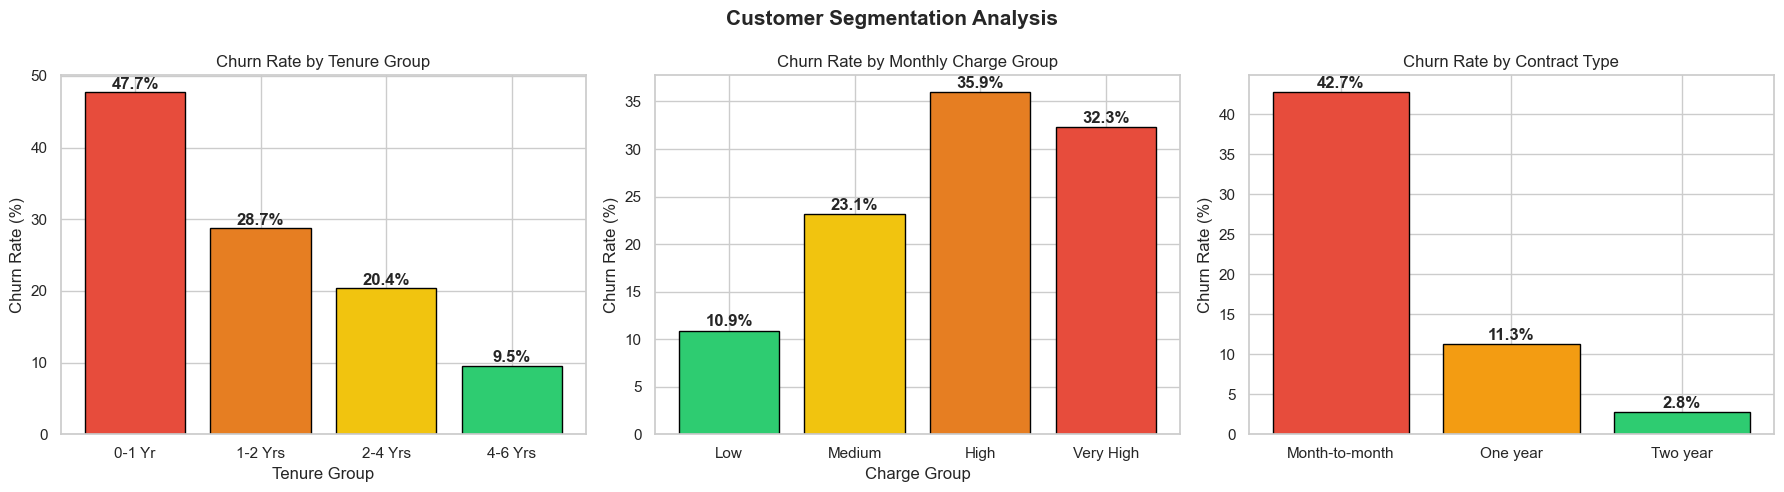

In [77]:
#  Plot 1: Churn Rate by Tenure Group 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Segmentation Analysis', fontsize=15, fontweight='bold')

# Tenure group
tenure_churn = df_eda.groupby('tenure_group', observed=True)['Churn'].mean() * 100
axes[0].bar(tenure_churn.index, tenure_churn.values,
            color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'], edgecolor='black')
for i, val in enumerate(tenure_churn.values):
    axes[0].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Churn Rate by Tenure Group')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Tenure Group')

# Charge group
charge_churn = df_eda.groupby('charge_group', observed=True)['Churn'].mean() * 100
axes[1].bar(charge_churn.index, charge_churn.values,
            color=['#2ecc71','#f1c40f','#e67e22','#e74c3c'], edgecolor='black')
for i, val in enumerate(charge_churn.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Monthly Charge Group')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Charge Group')

# Contract type
contract_churn2 = df_eda.groupby('Contract', observed=True)['Churn'].mean() * 100
axes[2].bar(contract_churn2.index, contract_churn2.values,
            color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
for i, val in enumerate(contract_churn2.values):
    axes[2].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')
axes[2].set_title('Churn Rate by Contract Type')
axes[2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('task3_plot1_segments.png', dpi=150, bbox_inches='tight')
plt.show()

High-Value At-Risk Customers: 1186
Avg Monthly Charges: $86.15
Avg Tenure: 16.2 months


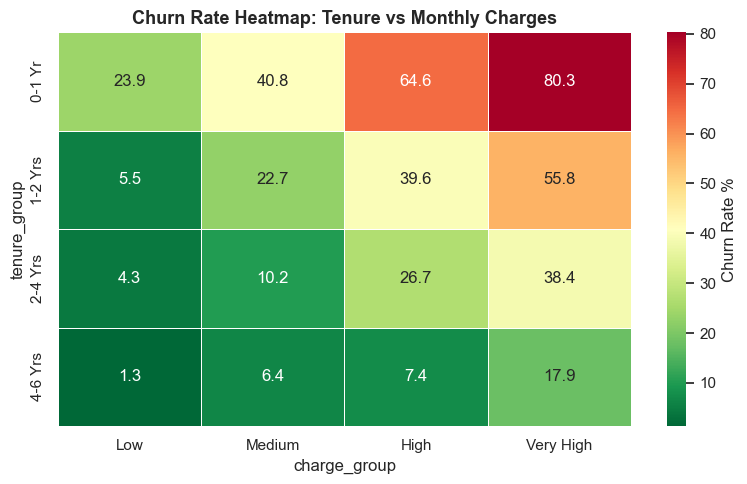

 Task 3 Complete!


In [79]:
# High Value At-Risk Customers 
# High value = High/Very High charges + Month-to-month contract
high_value_risk = df_eda[
    (df_eda['charge_group'].isin(['High', 'Very High'])) &
    (df_eda['Contract'] == 'Month-to-month') &
    (df_eda['Churn'] == 1)
]

print(f"High-Value At-Risk Customers: {len(high_value_risk)}")
print(f"Avg Monthly Charges: ${high_value_risk['MonthlyCharges'].mean():.2f}")
print(f"Avg Tenure: {high_value_risk['tenure'].mean():.1f} months")

# Heatmap: tenure group vs charge group churn rate
pivot = df_eda.pivot_table(values='Churn',
                            index='tenure_group',
                            columns='charge_group',
                            aggfunc='mean',
                            observed=True) * 100

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Churn Rate %'})
plt.title('Churn Rate Heatmap: Tenure vs Monthly Charges',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_plot2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Task 3 Complete!")

In [81]:
# TASK 4: CHURN PREDICTION MODEL
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
# !pip install imbalanced-learn  ← run this once if needed

# Scale Features 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Apply SMOTE 
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f"After SMOTE → Class 0: {sum(y_train_sm==0)}, Class 1: {sum(y_train_sm==1)}")

After SMOTE → Class 0: 4139, Class 1: 4139


In [83]:
# Train Multiple Models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    results[name] = {
        'model':    model,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'auc':      roc_auc_score(y_test, y_proba),
        'report':   classification_report(y_test, y_pred,
                        output_dict=True)
    }
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred,
          target_names=['No Churn', 'Churned']))


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
     Churned       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


  Decision Tree
              precision    recall  f1-score   support

    No Churn       0.89      0.74      0.81      1035
     Churned       0.51      0.75      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.76      1409


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.85      0.84      0.84      1035
     Churned       0.57      0.60      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg     

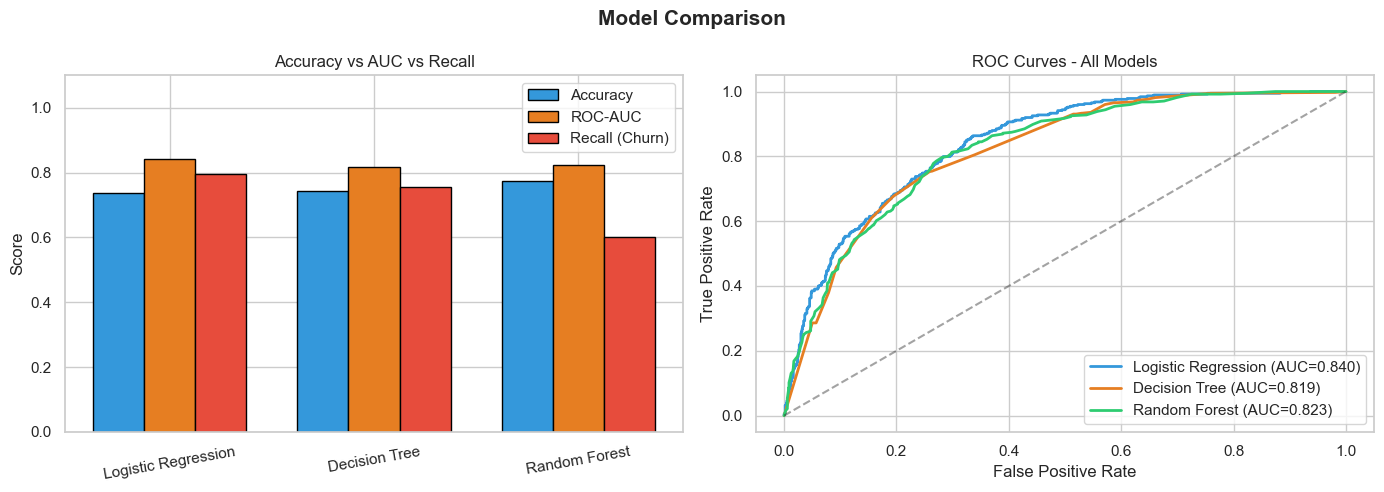

Task 4 Complete!


In [85]:
# Model Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison', fontsize=15, fontweight='bold')

model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
aucs        = [results[m]['auc']      for m in model_names]
recalls     = [results[m]['report']['1']['recall'] for m in model_names]

x     = np.arange(len(model_names))
width = 0.25

axes[0].bar(x - width, accuracies, width, label='Accuracy',
            color='#3498db', edgecolor='black')
axes[0].bar(x,          aucs,      width, label='ROC-AUC',
            color='#e67e22', edgecolor='black')
axes[0].bar(x + width,  recalls,   width, label='Recall (Churn)',
            color='#e74c3c', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Accuracy vs AUC vs Recall')
axes[0].legend()
axes[0].set_ylabel('Score')

# ROC curves
for name, color in zip(model_names, ['#3498db','#e67e22','#2ecc71']):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={results[name]['auc']:.3f})",
                 linewidth=2, color=color)
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4)
axes[1].set_title('ROC Curves - All Models')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('task4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Task 4 Complete!")